In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = (
    boston_housing.load_data()
)

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


In [ ]:
print(train_data.shape)
print(train_targets.shape)

print(test_data.shape)
print(test_targets.shape)

(404, 13)
(404,)
(102, 13)
(102,)


In [ ]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data = (train_data - mean) / std
test_data = (test_data - mean) / std

In [ ]:
len(train_data[0])

13

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(13,)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1
    )
])

/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    train_data,
    train_targets,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6729 - mae: 1.1373 - val_loss: 16.3690 - val_mae: 2.4490
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6808 - mae: 1.1404 - val_loss: 16.4994 - val_mae: 2.4590
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5488 - mae: 1.0814 - val_loss: 16.7213 - val_mae: 2.4657
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.5421 - mae: 1.1210 - val_loss: 16.0978 - val_mae: 2.4600
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6441 - mae: 1.1282 - val_loss: 16.1733 - val_mae: 2.4460
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6420 - mae: 1.1216 - val_loss: 16.8316 - val_mae: 2.4694
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6423 - mae: 1.1414 - val_loss: 18.3459 - val_mae: 2.6007
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6337 - mae: 1.1297 - val_loss: 16.2963 - val_mae: 2.4257
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - los

In [ ]:
test_loss, test_mae = model.evaluate(
    test_data,
    test_targets
)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.7337 - mae: 3.0108
Test MSE: 23.73373031616211
Test MAE: 3.0108203887939453


In [ ]:
sample = test_data[0].reshape(1, 13)

prediction = model.predict(sample)

print("Predicted:", prediction[0][0])
print("Actual:", test_targets[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted: 8.858002
Actual: 7.2


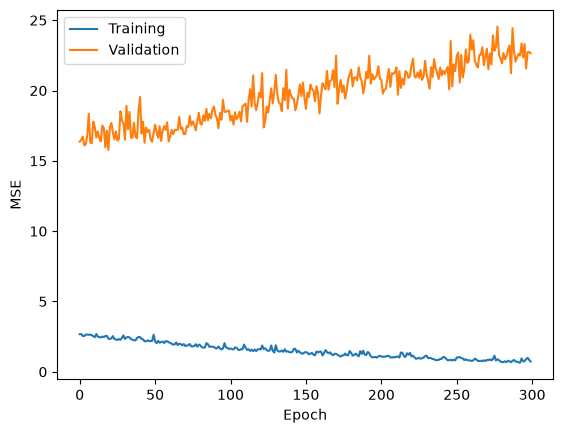

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

In [16]:
predictions = model.predict(test_data)

print("Predicted:", predictions[:5].flatten())
print("Actual:", test_targets[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predicted: [ 8.858004 19.417442 21.013044 29.974392 23.569727]
Actual: [ 7.2 18.8 19.  27.  22.2]


In [17]:
model.save("boston_house_model.keras")

In [18]:
model = tf.keras.models.load_model(
    "boston_house_model.keras"
)

In [19]:
prediction = model.predict(test_data)

print(prediction[:5])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[ 8.858004]
 [19.417442]
 [21.013044]
 [29.974392]
 [23.569727]]


In [20]:
model.save_weights("boston_house.weights.h5")

In [21]:
model.load_weights("boston_house.weights.h5")

In [22]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_boston_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [24]:
model.fit(
    train_data,
    train_targets,
    epochs=1000,
    batch_size=16,
    validation_split=0.2,
    callbacks=[checkpoint]
)

Epoch 1/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5377 - mae: 0.5124 - val_loss: 24.3101 - val_mae: 2.8809
Epoch 2/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5607 - mae: 0.5159 - val_loss: 25.5874 - val_mae: 2.9139
Epoch 3/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5089 - mae: 0.4786 - val_loss: 25.4356 - val_mae: 2.9085
Epoch 4/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5739 - mae: 0.4957 - val_loss: 23.9742 - val_mae: 2.8622
Epoch 5/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4393 - mae: 0.4439 - val_loss: 24.0776 - val_mae: 2.8851
Epoch 6/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4850 - mae: 0.4783 - val_loss: 23.9653 - val_mae: 2.8849
Epoch 7/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5218 - mae: 0.4909 - val_loss: 24.8655 - val_mae: 2.9199
Epoch 8/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4333 - mae: 0.4321 - val_loss: 24.9187 - val_mae: 2.8766
Epoch 9/1000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/s